# CV-Interval with Forward Oversmooth EM Refinement

This notebook demonstrates a **two-stage workflow** for **interval-censored** data on 
\([0,1]\):

## Stage 1 (CV Midpoint Initializer)
1. Generate interval-censored observations \([L_i, R_i]\).
2. Fit a **midpoint-imputed HAL-MLE** initializer with **Optuna CV**.
3. Optionally apply the **conservative adjustment** to pick the baseline \(\lambda^*\) and \(\text{basis\_order}^*\).

## Stage 2 (Oversmooth + EM)
4. Fit oversmoothed midpoint initializers with `factor × λ*` (factor < 1 = more regularized, fewer knots).
5. Forward-grid candidate selection by knot-count reduction.
6. Single-run EM refinement (no CV) for each candidate using **truncated-to-[L,R] multiple imputation**.
7. Return the best EM estimator by **interval log-likelihood** \(\sum_i \log(F(R_i)-F(L_i))\).



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.utils.dgp import TruncatedGMM
from haldensity.censoring import (
    IntervalCensoredOptunaHyperparameterTuner,
    IntervalCensoredEMStageOverSmoothTuner,
    incomplete_loglik_interval,
    kl_divergence,
)



/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def generate_inspection_intervals(n_samples: int, n_intervals: int, rng: np.random.Generator) -> np.ndarray:
    """Generate per-subject inspection grids.

    Returns array of shape (n_samples, n_intervals + 2) with boundaries including 0 and 1.
    """
    t = np.sort(rng.uniform(0.0, 1.0, size=(n_samples, n_intervals)), axis=1)
    t = np.hstack([np.zeros((n_samples, 1)), t, np.ones((n_samples, 1))])
    return t


def convert_to_interval_censored_data(T: np.ndarray, intervals: np.ndarray) -> pd.DataFrame:
    """Given true event times T and per-subject interval grids, return (L,R)."""
    L = np.empty_like(T, dtype=float)
    R = np.empty_like(T, dtype=float)
    for i, t in enumerate(T):
        left_idx = np.searchsorted(intervals[i], t, side="right") - 1
        left_idx = np.clip(left_idx, 0, intervals.shape[1] - 2)
        L[i] = float(intervals[i][left_idx])
        R[i] = float(intervals[i][left_idx + 1])
    return pd.DataFrame({"L": L, "R": R})



n=500, avg_width=0.3242, median_width=0.3110


,L,R
0,0.094177,0.438878
1,0.450386,0.761140
2,0.000000,0.370798
3,0.227239,0.554585
4,0.000000,0.354526


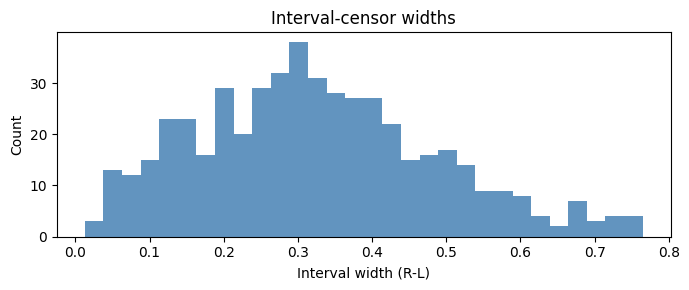

In [3]:
# Generate interval-censored data from a truncated GMM on [0,1]
rng = np.random.default_rng(42)

# True event-time distribution (bimodal)
event_dgp = TruncatedGMM(
    components=[
        {"mean": 0.30, "std": 0.08, "lower": 0.0, "upper": 1.0},
        {"mean": 0.70, "std": 0.10, "lower": 0.0, "upper": 1.0},
    ],
    weights=[0.45, 0.55],
)
T_star = event_dgp.generate_samples(500)

# Inspection scheme: each subject has its own random inspection times
n_intervals = 5
intervals = generate_inspection_intervals(n_samples=len(T_star), n_intervals=n_intervals, rng=rng)

data = convert_to_interval_censored_data(T_star, intervals)

print(f"n={len(data)}, avg_width={float((data['R']-data['L']).mean()):.4f}, median_width={float((data['R']-data['L']).median()):.4f}")
display(data.head())

# Quick look at interval widths
plt.figure(figsize=(7, 3))
plt.hist((data["R"] - data["L"]).values, bins=30, color="steelblue", alpha=0.85)
plt.xlabel("Interval width (R-L)")
plt.ylabel("Count")
plt.title("Interval-censor widths")
plt.tight_layout()
plt.show()



In [10]:
data

,L,R
0,0.094177,0.438878
1,0.450386,0.761140
2,0.000000,0.370798
3,0.227239,0.554585
4,0.000000,0.354526
...,...,...
495,0.373384,0.944144
496,0.505153,0.815731
497,0.608660,0.772506
498,0.402138,0.883666


In [4]:
# Stage 1: CV midpoint initializer (with conservative adjustment)

mid_tuner = IntervalCensoredOptunaHyperparameterTuner(
    estimator_name="IntervalCensoredMidpointEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 500.0, "log": True},
        "basis_order": [0, 1],  # Fix basis_order to 0 for this example
    },
    n_grid_points=200,
    use_conservative_adjustment=True,
    conservative_k_percent=0.005,
    silent=False,
    L_col="L",
    R_col="R",
)

mid_result = mid_tuner.optimize(n_trials=20)
best_mid_estimator = mid_tuner.fit_best_model()



IntervalCensored Optuna CV:  30%|███       | 6/20 [00:03<00:07,  1.80trial/s, LL=-120.49, best=-115.21]/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
IntervalCensored Optuna CV: 100%|██████████| 20/20 [00:11<00:00,  1.75trial/s, LL=-115.37, best=-115.19]


In [5]:
# Stage 2: oversmooth midpoint init + single-run EM refinement (NO CV)

tuner = IntervalCensoredEMStageOverSmoothTuner.from_midpoint_tuning_result(
    data,
    midpoint_tuning_result=mid_result,
    random_state=42,
    n_grid_points=200,
    oversmooth_factors=np.linspace(0.5, 1.0, 11),
    em_norm_factor=1.0,
    em_m_imputations=200,
    em_max_em_iter=30,
    em_tol=0.1,
    selection="em_ll",
    silent=True,
    L_col="L",
    R_col="R",
)

best_em_estimator = tuner.fit_best_estimator()



In [6]:
# Tuning results summary
assert tuner.init_records is not None
assert tuner.em_records is not None
assert tuner.best_em_record is not None

baseline = next(r for r in tuner.init_records if abs(float(r.factor) - 1.0) < 1e-12)

mid_res = best_mid_estimator.get_results()
mid_n_knots = len(mid_res.get("grid_points_hal_selected", []))
mid_ll_stage1 = float(incomplete_loglik_interval(best_mid_estimator, data, L_col="L", R_col="R"))

print("=" * 60)
print("Tuning Summary (Interval-Censored)")
print("=" * 60)
print(f"Conservative λ*:                {tuner.lambda_star:.4f}")
print(f"basis_order*:                   {tuner.basis_order_star}")
print(f"Candidates tested (EM runs):     {len(tuner.em_records)}")
print(f"Best factor:                    {tuner.best_em_record.factor:.2f}")
print(f"Best EM log-lik:                {tuner.best_em_record.em_ll:.4f}")
print(f"Best init LL (@best):           {tuner.best_em_record.init_ll:.4f}")
print(f"LL gain from EM (@best):        {tuner.best_em_record.ll_gain:.4f}")
print(f"n_knots (init @best):           {tuner.best_em_record.init_n_knots}")
print(f"n_knots (after EM @best):       {tuner.best_em_record.em_n_knots}")
print("-")
print(f"Stage-1 midpoint refit LL:          {mid_ll_stage1:.4f}")
print(f"Stage-1 midpoint refit n_knots:     {mid_n_knots}")
print(f"Baseline factor=1.00 init LL:       {baseline.log_likelihood:.4f}")
print(f"Baseline factor=1.00 init n_knots:  {baseline.n_knots}")
print("=" * 60)



Tuning Summary (Interval-Censored)
Conservative λ*:                7.0839
basis_order*:                   0
Candidates tested (EM runs):     9
Best factor:                    0.70
Best EM log-lik:                -562.6342
Best init LL (@best):           -573.8513
LL gain from EM (@best):        11.2171
n_knots (init @best):           23
n_knots (after EM @best):       23
-
Stage-1 midpoint refit LL:          -571.6570
Stage-1 midpoint refit n_knots:     34
Baseline factor=1.00 init LL:       -571.6570
Baseline factor=1.00 init n_knots:  34


In [7]:
# Show all candidate results
assert tuner.em_records is not None

records = [
    {
        "factor": r.factor,
        "init_n_knots": r.init_n_knots,
        "em_n_knots": r.em_n_knots,
        "init_ll": r.init_ll,
        "em_ll": r.em_ll,
        "ll_gain": r.ll_gain,
        "em_iters": r.em_iterations,
    }
    for r in tuner.em_records
]

df_records = pd.DataFrame(records).round(4)
display(df_records)



,factor,init_n_knots,em_n_knots,init_ll,em_ll,ll_gain,em_iters
0,0.55,18,18,-577.7252,-563.2436,14.4816,8
1,0.60,20,20,-576.2467,-563.2768,12.9700,8
2,0.65,22,22,-574.9578,-562.6473,12.3105,9
3,0.70,23,23,-573.8513,-562.6342,11.2171,9
4,0.75,25,25,-573.0710,-563.1029,9.9681,9
5,0.80,27,27,-572.5710,-563.1094,9.4616,9
6,0.90,29,29,-572.0160,-563.1176,8.8983,9
7,0.95,32,32,-571.8082,-562.9798,8.8284,9
8,1.00,34,34,-571.6570,-564.7920,6.8650,6


In [8]:
# Evaluate Stage-1 vs Stage-2 using KL divergence (truth is known in this simulation)
assert tuner.best_em_record is not None

grid = np.linspace(0, 1, 500)
true_pdf = event_dgp.compute_density(grid)

mid_pdf = best_mid_estimator.get_density_at_points(grid)
em_pdf = best_em_estimator.get_density_at_points(grid)

mid_ll = incomplete_loglik_interval(best_mid_estimator, data, L_col="L", R_col="R")
em_ll = incomplete_loglik_interval(best_em_estimator, data, L_col="L", R_col="R")

mid_kl = kl_divergence(true_pdf_fn=lambda x: event_dgp.compute_density(x), grid=grid, est_density=mid_pdf)
em_kl = kl_divergence(true_pdf_fn=lambda x: event_dgp.compute_density(x), grid=grid, est_density=em_pdf)

comparison = pd.DataFrame(
    [
        {"model": "Stage 1: CV Midpoint (fit_best_model)", "ll": float(mid_ll), "kl": float(mid_kl)},
        {
            "model": f"Stage 2: Oversmooth+EM (best factor={tuner.best_em_record.factor:.2f})",
            "ll": float(em_ll),
            "kl": float(em_kl),
        },
    ]
)

print("=" * 60)
print("Performance vs truth (lower KL is better)")
print("=" * 60)
print(comparison.to_string(index=False))
print("=" * 60)
print(f"ΔKL (EM - Midpoint): {float(em_kl - mid_kl):+.6f}")
print(f"ΔLL (EM - Midpoint): {float(em_ll - mid_ll):+.6f}")
print("=" * 60)

display(comparison)



Performance vs truth (lower KL is better)
                                    model          ll       kl
    Stage 1: CV Midpoint (fit_best_model) -571.657005 0.077348
Stage 2: Oversmooth+EM (best factor=0.70) -562.634212 0.054848
ΔKL (EM - Midpoint): -0.022500
ΔLL (EM - Midpoint): +9.022792


,model,ll,kl
0,Stage 1: CV Midpoint (fit_best_model),-571.657005,0.077348
1,Stage 2: Oversmooth+EM (best factor=0.70),-562.634212,0.054848


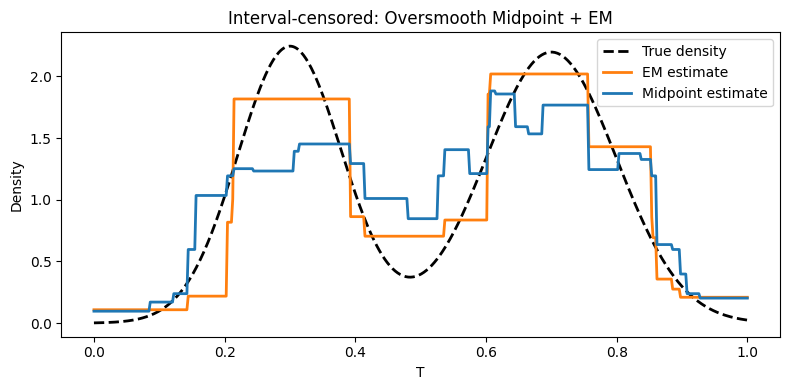

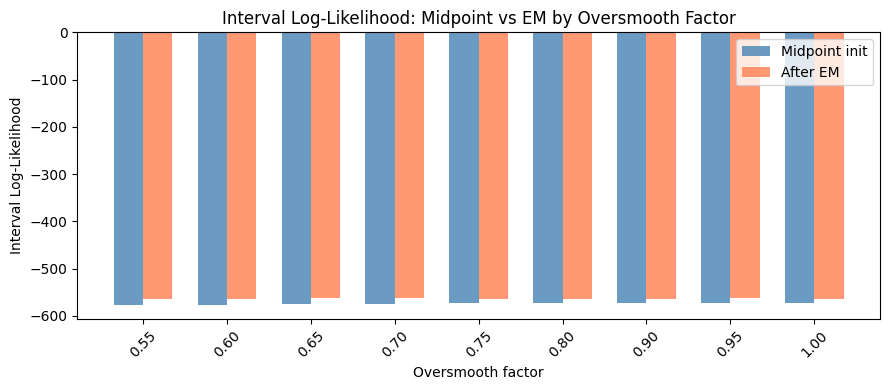

In [9]:
# Plot estimated vs true density
plt.figure(figsize=(8, 4))
plt.plot(grid, true_pdf, "k--", lw=2, label="True density")
plt.plot(grid, em_pdf, "C1-", lw=2, label="EM estimate")
plt.plot(grid, mid_pdf, "C0-", lw=2, label="Midpoint estimate")
plt.xlabel("T")
plt.ylabel("Density")
plt.title("Interval-censored: Oversmooth Midpoint + EM")
plt.legend()
plt.tight_layout()
plt.show()

# Bar chart: init LL vs EM LL by factor
assert tuner.em_records is not None
_df = pd.DataFrame([
    {"factor": r.factor, "init_ll": r.init_ll, "em_ll": r.em_ll}
    for r in tuner.em_records
])

x = np.arange(len(_df))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, _df["init_ll"], width, label="Midpoint init", color="steelblue", alpha=0.8)
ax.bar(x + width/2, _df["em_ll"], width, label="After EM", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{f:.2f}" for f in _df["factor"]], rotation=45)
ax.set_xlabel("Oversmooth factor")
ax.set_ylabel("Interval Log-Likelihood")
ax.legend()
ax.set_title("Interval Log-Likelihood: Midpoint vs EM by Oversmooth Factor")
plt.tight_layout()
plt.show()

